# Lecture 8 - (30/06/2026)

Today's Topics:

- Taxomony of Machine Learning
- K-Means Clustering
- Hierarchical Agglomerative Clustering
- Weaknesses of $k$-means
- Gausian Mixture Models
- GMM Density Estimation
- Histogram Density
- Kernel Density Estimation

Last time, we began our journey into unsupervised learning by discussing Principal Component Analysis (PCA).

In this lecture, we will explore another very popular unsupervised learning concept: clustering. Clustering allows us to “group” similar datapoints together without being given labels of what “class” or where each point explicitly comes from.

## Taxomony of Machine Learning

### Supervised Learning

In supervised learning, our goal is to create a function that maps inputs to outputs. Each model is learned from example input/output pairs (training set), validated using input/output pairs, and eventually tested on more input/output pairs. Each pair consists of:

- Input vector (features)
- Output value (label)

In regression, our output value is quantitative, and in classification, our output value is categorical.

![image](https://www.mathworks.com/discovery/machine-learning-models/_jcr_content/mainParsys/band_copy_copy/mainParsys/lockedsubnav/mainParsys/columns/a32c7d5d-8012-4de1-bc76-8bd092f97db8/image_copy_217773679.adapt.full.medium.svg/1781600585633.svg)

### Unsupervised Learning

In unsupervised learning, our goal is to identify patterns in unlabeled data. In this type of learning, we do not have input/output pairs. Sometimes, we may have labels but choose to ignore them (e.g. PCA on labeled data). Instead, we are more interested in the inherent structure of the data we have rather than trying to simply predict a label using that structure of data. For example, if we are interested in dimensionality reduction, we can use PCA to reduce our data to a lower dimension.

Now, let’s consider a new problem: clustering.

### Clustering Examples

First off, let's see some use cases for clustering

#### Example 1 - Image Compression

Clustering can be used for image compression. Why? Digital images consume significant storage and bandwidth, so reducing the number of colors simplifies images while retaining their visual appeal.

- Clustering can group similar colors (pixels) in an image into clusters.
- Each cluster represents a color centroid (mean color of the group).
- Replace each pixel in the image with the color of its cluster centroid, reducing the number of unique colors.


#### Example 2 - Clustering in Social Networks

In social network clustering, we identify groups (clusters or communities) of individuals who interact more frequently with each other. This can help analyze network behavior, predict relationships, and recommend connections. Some applications include:

- Detecting communities on social network platforms.
- Understanding collaboration in organizations.
- Optimizing targeted marketing strategies.

#### Example 3 - Clustering in Climate Sciences

Clustering in climate science helps to identify patterns in large, complex datasets and provide insights into global and regional climate trends. Some examples include:

- Climate zone identification
- Weather pattern analysis
- Environmental monitoring


There are many types of clustering algorithms, and they all have strengths, inherent weaknesses, and different use cases. There are two main groups of clustering algorithms we will focus on: Agglomerative approaches to clustering, and Partitional approaches to clustering.

We will first focus on a partitional approach: K-Means clustering.

## K-Means Clustering

The most popular clustering approach is K-Means. The algorithm itself entails the following:

1. Pick an arbitrary $k$, and randomly place $k$ “centers”, each a different color.
2. Repeat until convergence:
   1. Color points according to the closest center (also called centroids). b. Move the center for each color to the center of points with that color.

In [10]:
import numpy as np
import plotly.graph_objects as go
from sklearn.cluster import KMeans

np.random.seed(42)

blob1 = np.random.normal(loc=[2, 2], scale=1.0, size=(600, 2))
blob2 = np.random.normal(loc=[8, 8], scale=1.2, size=(50, 2))
X = np.vstack((blob1, blob2))

k = 2
max_iter = 10

centroids = X[np.random.choice(len(X), k, replace=False)]

frames = []

for i in range(max_iter):
    distances = np.linalg.norm(X[:, None] - centroids, axis=2)
    labels = np.argmin(distances, axis=1)

    frames.append(go.Frame(
        data=[
            go.Scatter(
                x=X[:, 0],
                y=X[:, 1],
                mode='markers',
                marker=dict(color=labels, colorscale='Viridis', size=5),
            ),
            go.Scatter(
                x=centroids[:, 0],
                y=centroids[:, 1],
                mode='markers',
                marker=dict(color='red', size=14, symbol='x'),
            )
        ],
        name=f"Iteration {i}"
    ))

    new_centroids = np.array([
        X[labels == j].mean(axis=0) if np.any(labels == j) else centroids[j]
        for j in range(k)
    ])

    if np.allclose(centroids, new_centroids):
        break

    centroids = new_centroids

fig = go.Figure(
    data=frames[0].data,
    frames=frames
)

fig.update_layout(
    title="K-Means Iterations",
    xaxis_title="Feature 1",
    yaxis_title="Feature 2",
    template="plotly_white",
    updatemenus=[{
        "type": "buttons",
        "buttons": [
            {"label": "Play", "method": "animate", "args": [None]},
            {"label": "Pause", "method": "animate", "args": [[None], {"frame": {"duration": 0}}]}
        ]
    }],
    sliders=[{
        "steps": [
            {
                "method": "animate",
                "label": f"{i}",
                "args": [[f"Iteration {i}"], {"mode": "immediate"}]
            }
            for i in range(len(frames))
        ]
    }]
)

fig.show()

---

Note: K-Means is a completely different algorithm than K-Nearest Neighbors. K-means is used for clustering, where each point is assigned to one of $K$ clusters. On the other hand, K-Nearest Neighbors is used for classification (or, less often, regression), and the predicted value is typically the most common class among the $K$-nearest data points in the training set.

One major difference between these two is that $K$-Nearest Neighbors is used for supervised learning, where we have labeled input and output pairs, and $K$-means is used for unsupervised learning, where we only have features, and no label that we’re trying to predict.

The names may be similar, but there isn’t really anything in common.

---

Due to the randomness of where the $K$ centers initialize/start, you will get a different output/clustering every time you run $K$-Means. Consider three possible $K$-Means outputs; the algorithm has converged, and the colors denote the final cluster they are clustered as.

In [ ]:
import numpy as np
import plotly.graph_objects as go
from sklearn.cluster import KMeans
from plotly.subplots import make_subplots

np.random.seed(42)

blob1 = np.random.normal(loc=[2, 2], scale=1.0, size=(600, 2))
blob2 = np.random.normal(loc=[4, 4], scale=1.2, size=(50, 2))
X = np.vstack((blob1, blob2))

k = 4
seeds = [0, 1, 2, 3]

fig = make_subplots(rows=2, cols=2, subplot_titles=[f"Seed {s}" for s in seeds])

for idx, seed in enumerate(seeds):
    kmeans = KMeans(n_clusters=k, random_state=seed)
    labels = kmeans.fit_predict(X)
    centers = kmeans.cluster_centers_

    row = idx // 2 + 1
    col = idx % 2 + 1

    fig.add_trace(
        go.Scatter(
            x=X[:, 0],
            y=X[:, 1],
            mode='markers',
            marker=dict(color=labels, colorscale='Viridis', size=5, opacity=0.7),
            showlegend=False
        ),
        row=row, col=col
    )

    fig.add_trace(
        go.Scatter(
            x=centers[:, 0],
            y=centers[:, 1],
            mode='markers',
            marker=dict(color='red', size=12, symbol='x'),
            showlegend=False
        ),
        row=row, col=col
    )

fig.update_layout(
    title="K-Means with k=4",
    template="plotly_white",
    height=800
)

fig.show()

Which clustering output is the best? To evaluate different clustering results, we need a loss function.

The two common loss functions are:

- Inertia: Sum of squared distances from each data point to its center.
- Distortion: Weighted sum of squared distances from each data point to its center.

It turns out that the function K-Means is trying to minimize is inertia, but often fails to find global optimum. Why does this happen? We can think of K-means as a pair of optimizers that take turns. The first optimizer holds center positions constant and optimizes data colors. The second optimizer holds data colors constant and optimizes center positions.

This is a hard problem: give an algorithm that optimizes inertia FOR A GIVEN $K$; $K$ is picked in advance. Your algorithm should return the EXACT best centers and colors, but you don’t need to worry about runtime.

We won't dwell too much on this problem as it delves deep into material from CSCI 350/353/761.

- For all possible $k^n$ colorings:
  - Compute the $k$ centers for that coloring
  - Compute the inertia for the $k$ centers
    - If the current inertia is better than the best known, write down the current centers and colorng and call that the new best known

No better algorithm has been found for solving the problem of minimizing inertia exactly.

## Hierarchical Agglomerative Clustering

![image](https://media.geeksforgeeks.org/wp-content/uploads/20251117144305409428/agglomerative_clustering.webp)

Now, let us introduce Hierarchical Agglomerative Clustering! We start with every data point in a separate cluster, and we’ll keep merging the most similar pairs of data points/clusters until we have one big cluster left. This is called a bottom-up or agglomerative method.

There are various ways to decide the order of combining clusters called Linkage Criterion:

- **Single linkage** (similarity of the most similar): the distance between two clusters as the minimum distance between a point in the first cluster and a point in the second.
- **Average linkage**: the distance between two clusters as the average of all pairwise distances between points in the first cluster and points in the second.
- **Complete linkage** (similarity of the least similar): the distance between two clusters as the maximum distance between a point in the first cluster and a point in the second.

The linkage criterion decides how we measure the “distance” between two clusters.

When the algorithm starts, every data point is in its own cluster. In the plot below, there are 12 data points, so the algorithm starts with 12 clusters. As the clustering begins, it assesses which clusters are the closest together.

In [20]:
import numpy as np
import plotly.graph_objects as go
from scipy.cluster.hierarchy import linkage, fcluster

np.random.seed(42)
X = np.random.rand(12, 2) * 10

Z = linkage(X, method='ward')

max_clusters = len(X)

frames = []

for t in range(max_clusters, 0, -1):
    labels = fcluster(Z, t, criterion='maxclust')
    
    cluster_traces = []
    for cluster_id in np.unique(labels):
        cluster_points = X[labels == cluster_id]
        if len(cluster_points) > 1:
            cluster_traces.append(go.Scatter(
                x=cluster_points[:, 0],
                y=cluster_points[:, 1],
                mode='lines+markers',
                line=dict(width=2),
                marker=dict(size=12),
                name=f"Cluster {cluster_id}",
                showlegend=False
            ))
        else:
            cluster_traces.append(go.Scatter(
                x=cluster_points[:, 0],
                y=cluster_points[:, 1],
                mode='markers',
                marker=dict(size=12),
                name=f"Cluster {cluster_id}",
                showlegend=False
            ))
    
    frames.append(go.Frame(data=cluster_traces, name=f"{t} clusters"))

fig = go.Figure(
    data=frames[0].data,
    frames=frames
)

fig.update_layout(
    title="Hierarchical Clustering",
    xaxis_title="X",
    yaxis_title="Y",
    template="plotly_white",
    updatemenus=[{
        "type": "buttons",
        "buttons": [
            {"label": "Play", "method": "animate", "args": [None]},
            {"label": "Pause", "method": "animate", "args": [[None], {"frame": {"duration": 0}}]}
        ]
    }],
    sliders=[{
        "steps": [
            {"method": "animate",
             "label": frame.name,
             "args": [[frame.name], {"mode": "immediate"}]}
            for frame in frames
        ],
        "currentvalue": {"prefix": "Clusters: "}
    }]
)

fig.show()

### Clustering, Dendrograms, and Intuition

Agglomerative clustering is one form of “hierarchical clustering.” It is interpretable because we can keep track of when two clusters got merged (each cluster is a tree), and we can visualize the merging hierarchy, resulting in a “dendrogram.” Won’t discuss this in detail for this course, but you might see these in the wild. Here are some examples:

In [23]:
import numpy as np
import plotly.graph_objects as go
from scipy.cluster.hierarchy import linkage, dendrogram

# 12 points in 2D
np.random.seed(42)
X = np.random.rand(12, 2) * 10

# Hierarchical clustering
Z = linkage(X, method='ward')

# Dendrogram info
dendro = dendrogram(Z, no_plot=True)

# Coordinates for dendrogram lines
icoord = np.array(dendro['icoord'])
dcoord = np.array(dendro['dcoord'])

# Create figure with 1x2 subplots
from plotly.subplots import make_subplots
fig = make_subplots(rows=1, cols=2, subplot_titles=["Dendrogram", "Cluster Tree (2D)"])

# 1. Dendrogram (left panel)
for i in range(len(icoord)):
    fig.add_trace(
        go.Scatter(x=icoord[i], y=dcoord[i], mode='lines', line=dict(color='blue', width=2), showlegend=False),
        row=1, col=1
    )

# 2. 2D cluster tree (right panel)
# Map dendrogram leaf order to X coordinates
leaf_order = dendro['leaves']
ordered_X = X[leaf_order]

# Plot points
fig.add_trace(
    go.Scatter(x=ordered_X[:,0], y=ordered_X[:,1], mode='markers+text', marker=dict(size=12, color='red'),
               text=[str(i) for i in leaf_order], textposition='top center'),
    row=1, col=2
)

# Plot cluster merging lines in 2D tree
for i in range(len(Z)):
    c1, c2 = int(Z[i, 0]), int(Z[i, 1])
    # Map cluster indices to 2D positions
    if c1 < 12: x1, y1 = X[c1]
    else: x1, y1 = ordered_X[c1 - 12]  # merged cluster approximate
    if c2 < 12: x2, y2 = X[c2]
    else: x2, y2 = ordered_X[c2 - 12]

    fig.add_trace(
        go.Scatter(x=[x1, x2], y=[y1, y2], mode='lines', line=dict(color='blue', width=2), showlegend=False),
        row=1, col=2
    )

fig.update_layout(height=600, width=1000, template="plotly_white", title_text="Hierarchical Clustering: Dendrogram & 2D Tree")
fig.show()

## Weaknesses of $k$-means

The $k$-means clustering model from last time is simple and relatively easy to understand, but its simplicity leads to practical challenges in its application. In particular, the non-probabilistic nature of $k$-means and its use of simple distance-from-cluster-center to assign cluster membership leads to poor performance for many real-world situations.

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns; sns.set()
import plotly.express as px
import plotly.graph_objects as go
from sklearn.cluster import KMeans
from scipy.spatial.distance import cdist
from scipy.stats import norm
import sklearn
import numpy as np

As we saw last lecture, given simple, well-separated data, $k$-means finds suitable clustering results.

For example, if we have simple blobs of data, the $k$-means algorithm can quickly label those clusters in a way that closely matches what we might do by eye:

In [ ]:
# Generate some data
from sklearn.datasets import make_blobs
X, y_true = make_blobs(n_samples=400, centers=4,
                       cluster_std=0.60, random_state=0)
X = X[:, ::-1]

In [ ]:
from sklearn.cluster import KMeans

kmeans = KMeans(4, random_state=0)
labels = kmeans.fit(X).predict(X)

px.scatter(x=X[:, 0], y=X[:, 1], color=labels, color_continuous_scale='viridis')

From an intuitive standpoint, we might expect that the clustering assignment for some points is more certain than others: for example, there appears to be a very slight overlap between the two middle clusters, such that we might not have complete confidence in the cluster assigment of points between them. Unfortunately, the k-means model has no intrinsic measure of probability or uncertainty of cluster assignments.

One way to think about the k-means model is that it places a circle (or, in higher dimensions, a hyper-sphere) at the center of each cluster, with a radius defined by the most distant point in the cluster. This radius acts as a hard cutoff for cluster assignment within the training set: any point outside this circle is not considered a member of the cluster.

In [ ]:
def plot_kmeans(kmeans, X, n_clusters=4, rseed=0):
    labels = kmeans.fit_predict(X)

    # Scatter points
    fig = go.Figure()

    fig.add_trace(go.Scatter(
        x=X[:, 0],
        y=X[:, 1],
        mode='markers',
        marker=dict(
            size=8,
            color=labels,
            colorscale='Viridis',
            showscale=True
        ),
        name='Data'
    ))

    # Compute centers and radii
    centers = kmeans.cluster_centers_
    radii = [
        cdist(X[labels == i], [center]).max()
        for i, center in enumerate(centers)
    ]

    # Add circles as shapes
    shapes = []
    for center, r in zip(centers, radii):
        shapes.append(dict(
            type="circle",
            xref="x",
            yref="y",
            x0=center[0] - r,
            y0=center[1] - r,
            x1=center[0] + r,
            y1=center[1] + r,
            line=dict(color="rgba(150,150,150,0.8)", width=3),
            fillcolor="rgba(200,200,200,0.3)"
        ))

    fig.update_layout(
        shapes=shapes,
        xaxis=dict(scaleanchor="y"),  # equal aspect ratio
        yaxis=dict(),
        title="KMeans Clustering"
    )

    return fig

In [ ]:
kmeans = KMeans(n_clusters=4, random_state=0)
plot_kmeans(kmeans, X)

An important observation for k-means is that these cluster models must be circular: k-means has no built-in way of accounting for oblong or elliptical clusters. So, for example, if we take the same data and transform it, the cluster assignments end up becoming muddled:

In [ ]:
rng = np.random.RandomState(13)
X_stretched = np.dot(X, rng.randn(2, 2))

kmeans = KMeans(n_clusters=4, random_state=0)
plot_kmeans(kmeans, X_stretched)

By eye, we recognize that these transformed clusters are non-circular, and thus circular clusters would be a poor fit. Nevertheless, k-means is not flexible enough to account for this, and tries to force-fit the data into four circular clusters.

These two disadvantages of k-means:

- its lack of flexibility in cluster shape 

- its lack of probabilistic cluster assignment
 
mean that for many datasets (especially low-dimensional datasets) it may not perform as well as you might hope.

## Gaussian Mixture Models

A Gaussian mixture model (GMM) attempts to find a mixture of multi-dimensional Gaussian probability distributions that best model any input dataset. In the simplest case, GMMs can be used for finding clusters in the same manner as k-means:

In [ ]:
from sklearn.mixture import GaussianMixture
gmm = GaussianMixture(n_components=4).fit(X)
labels = gmm.predict(X)
px.scatter(x=X[:, 0], y=X[:, 1], color=labels, color_continuous_scale='viridis')

But because GMM contains a probabilistic model under the hood, it is also possible to find probabilistic cluster assignments - in Scikit-Learn this is done using the `predict_proba` method. This returns a matrix of size `[n_samples, n_clusters]` which measures the probability that any point belongs to the given cluster:

In [ ]:
probs = gmm.predict_proba(X)
print(probs[:5].round(3))

[[0.531 0.469 0.    0.   ]
 [0.    0.    0.    1.   ]
 [0.    0.    0.    1.   ]
 [1.    0.    0.    0.   ]
 [0.    0.    0.    1.   ]]


We can visualize this uncertainty by, for example, making the size of each point proportional to the certainty of its prediction; looking at the following figure, we can see that it is precisely the points at the boundaries between clusters that reflect this uncertainty of cluster assignment:

In [ ]:
size = 10 * probs.max(1) ** 2
px.scatter(x=X[:, 0], y=X[:, 1], color=labels, color_continuous_scale='viridis', size=size)

Under the hood, a Gaussian mixture model is very similar to k-means: it uses an expectation–maximization approach which qualitatively does the following:

1. Choose starting guesses for the location and shape
2. Repeat until converged:
   1. E-step: for each point, find weights encoding the probability of membership in each cluster
   2. M-step: for each cluster, update its location, normalization, and shape based on all data points, making use of the weights

The result of this is that each cluster is associated not with a hard-edged sphere, but with a smooth Gaussian model. Just as in the k-means expectation–maximization approach, this algorithm can sometimes miss the globally optimal solution, and thus in practice multiple random initializations are used.

In [ ]:
def draw_ellipse(fig, position, covariance, weight, w_factor):
    # SVD to get axes and rotation
    if covariance.shape == (2, 2):
        U, s, _ = np.linalg.svd(covariance)
        angle = np.arctan2(U[1, 0], U[0, 0])
        width, height = 2 * np.sqrt(s)
    else:
        angle = 0
        width, height = 2 * np.sqrt(covariance)
    
    t = np.linspace(0, 2*np.pi, 100)

    for nsig in range(1, 4):
        # ellipse parametric form
        x = nsig * width / 2 * np.cos(t)
        y = nsig * height / 2 * np.sin(t)

        # rotation
        R = np.array([
            [np.cos(angle), -np.sin(angle)],
            [np.sin(angle),  np.cos(angle)]
        ])
        ellipse = R @ np.vstack((x, y))

        fig.add_trace(go.Scatter(
            x=ellipse[0] + position[0],
            y=ellipse[1] + position[1],
            mode='lines',
            line=dict(width=2),
            opacity=weight * w_factor * 3,
            showlegend=False
        ))


def plot_gmm(gmm, X, label=True):
    labels = gmm.fit(X).predict(X)

    fig = go.Figure()

    # scatter points
    fig.add_trace(go.Scatter(
        x=X[:, 0],
        y=X[:, 1],
        mode='markers',
        marker=dict(
            size=8,
            color=labels if label else None,
            colorscale='Viridis',
            showscale=label
        ),
        name='Data'
    ))

    # equal aspect ratio
    fig.update_layout(
        xaxis=dict(scaleanchor="y"),
        title="Gaussian Mixture Model"
    )

    # draw ellipses
    w_factor = 0.2 / gmm.weights_.max()

    for pos, covar, w in zip(gmm.means_, gmm.covariances_, gmm.weights_):
        draw_ellipse(fig, pos, covar, w, w_factor)

    return fig

With this in place, we can take a look at what the four-component GMM gives us for our initial data:

In [ ]:
gmm = GaussianMixture(n_components=4, random_state=42)
plot_gmm(gmm, X)

Similarly, we can use the GMM approach to fit our stretched dataset; allowing for a full covariance the model will fit even very oblong, stretched-out clusters:

In [ ]:
gmm = GaussianMixture(n_components=4, covariance_type='full', random_state=42)
plot_gmm(gmm, X_stretched)

## GMM Density Estimation

Though GMM is often categorized as a clustering algorithm, fundamentally it is an algorithm for density estimation. That is to say, the result of a GMM fit to some data is technically not a clustering model, but a generative probabilistic model describing the distribution of the data.

In [ ]:
from sklearn.datasets import make_moons
Xmoon, ymoon = make_moons(200, noise=.05, random_state=0)
px.scatter(x=Xmoon[:, 0], y=Xmoon[:, 1])

If we try to fit this with a two-component GMM viewed as a clustering model, the results are not particularly useful:

In [ ]:
gmm2 = GaussianMixture(n_components=2, covariance_type='full', random_state=0)
plot_gmm(gmm2, Xmoon)

But if we instead use many more components and ignore the cluster labels, we find a fit that is much closer to the input data:

In [ ]:
gmm16 = GaussianMixture(n_components=16, covariance_type='full', random_state=0)
plot_gmm(gmm16, Xmoon, label=False)

Here the mixture of 16 Gaussians serves not to find separated clusters of data, but rather to model the overall distribution of the input data. This is a generative model of the distribution, meaning that the GMM gives us the recipe to generate new random data distributed similarly to our input. For example, here are 400 new points drawn from this 16-component GMM fit to our original data:

In [ ]:
Xnew, ynew = gmm16.sample(400)
px.scatter(x=Xnew[:, 0], y=Xnew[:, 1])

### How many components to use?

The fact that GMM is a generative model gives us a natural means of determining the optimal number of components for a given dataset. A generative model is inherently a probability distribution for the dataset, and so we can simply evaluate the likelihood of the data under the model, using cross-validation to avoid over-fitting.

Another means of correcting for over-fitting is to adjust the model likelihoods using some analytic criterion such as the [Akaike information criterion (AIC)](https://en.wikipedia.org/wiki/Akaike_information_criterion) or the [Bayesian information criterion (BIC)](https://en.wikipedia.org/wiki/Bayesian_information_criterion).

Let's look at the AIC and BIC as a function as the number of GMM components for our moon dataset:

In [ ]:
n_components = np.arange(1, 21)

models = [
    GaussianMixture(n_components=n, covariance_type='full', random_state=0).fit(Xmoon)
    for n in n_components
]

bic = [m.bic(Xmoon) for m in models]
aic = [m.aic(Xmoon) for m in models]

fig = go.Figure()

fig.add_trace(go.Scatter(
    x=n_components,
    y=bic,
    mode='lines+markers',
    name='BIC'
))

fig.add_trace(go.Scatter(
    x=n_components,
    y=aic,
    mode='lines+markers',
    name='AIC'
))

fig.update_layout(
    title="Model Selection: BIC vs AIC",
    xaxis_title="n_components",
    yaxis_title="Score",
    legend=dict(x=0.01, y=0.99)
)

fig.show()

The optimal number of clusters is the value that minimizes the AIC or BIC, depending on which approximation we wish to use.

- The AIC tells us that our choice of 16 components above was probably too many: around 8-12 components would have been a better choice.
- The BIC says that we should opt for a simpler model around 5-8 components.

Notice the important point: this choice of number of components measures how well GMM works as a density estimator, not how well it works as a clustering algorithm. I'd recommed you to think of GMM primarily as a density estimator, and use it for clustering only when warranted within simple datasets.

## Histograms Density

For one dimensional data, you are probably already familiar with one simple density estimator: the histogram. A histogram divides the data into discrete bins, counts the number of points that fall in each bin, and then visualizes the results in an intuitive manner.

For example, let's create some data that is drawn from two normal distributions:

In [ ]:
def make_data(N, f=0.3, rseed=1):
    rand = np.random.RandomState(rseed)
    x = rand.randn(N)
    x[int(f * N):] += 5
    return x

x = make_data(1000)

We have previously seen that the standard count-based histogram. By specifying the normed parameter of the histogram, we end up with a normalized histogram where the height of the bins does not reflect counts, but instead reflects probability density:

In [ ]:
px.histogram(x=x, nbins=30, histnorm='density')

One of the issues with using a histogram as a density estimator is that the choice of bin size and location can lead to representations that have qualitatively different features.

But what if, instead of stacking the blocks aligned with the bins, we were to stack the blocks aligned with the points they represent? If we do this, the blocks won't be aligned, but we can add their contributions at each location along the x-axis to find the result. Let's try this:

In [ ]:
x_d = np.linspace(-4, 10, 2000)
density = sum((abs(xi - x_d) < 0.5) for xi in x)

fig = go.Figure()

# Filled density area
fig.add_trace(go.Scatter(
    x=x_d,
    y=density,
    mode='lines',
    fill='tozeroy',
    opacity=0.5,
    name='Density'
))

# Rug plot (ticks at bottom)
fig.add_trace(go.Scatter(
    x=x,
    y=np.full_like(x, -0.1),
    mode='markers',
    marker=dict(symbol='line-ns-open', size=10),
    name='Samples'
))

# Axis limits
fig.update_layout(
    xaxis=dict(range=[-4, 10]),
    yaxis=dict(range=[-0.2, 300]),
    title="Density Estimate with Rug Plot"
)

fig.show()

The result looks a bit messy, but is a much more robust reflection of the actual data characteristics than is the standard histogram. Still, the rough edges are not aesthetically pleasing, nor are they reflective of any true properties of the data. In order to smooth them out, we might decide to replace the blocks at each location with a smooth function, like a Gaussian. Let's use a standard normal curve at each point instead of a block:

In [ ]:
density = sum(norm(xi).pdf(x_d) for xi in x)

fig = go.Figure()

# Filled density curve
fig.add_trace(go.Scatter(
    x=x_d,
    y=density,
    mode='lines',
    fill='tozeroy',
    opacity=0.5,
    name='Density'
))

# Rug plot
fig.add_trace(go.Scatter(
    x=x,
    y=np.full_like(x, -0.1),
    mode='markers',
    marker=dict(symbol='line-ns-open', size=10, color='black'),
    name='Samples'
))

# Axis limits
fig.update_layout(
    xaxis=dict(range=[-4, 10]),
    yaxis=dict(range=[-0.2, 250]),
    title="Gaussian KDE via Summed PDFs"
)

fig.show()

This smoothed-out plot, with a Gaussian distribution contributed at the location of each input point, gives a much more accurate idea of the shape of the data distribution, and one which has much less variance (i.e., changes much less in response to differences in sampling).

These last two plots are examples of kernel density estimation in one dimension: the first uses a so-called "tophat" kernel and the second uses a Gaussian kernel. We'll now look at kernel density estimation in more detail.

![image](https://blogs.sas.com/content/iml/files/2016/07/kdecomponents1.png)

## Kernel Density Estimation

The free parameters of kernel density estimation are the kernel, which specifies the shape of the distribution placed at each point, and the kernel bandwidth, which controls the size of the kernel at each point.

Let's first show a simple example of replicating the above plot using the Scikit-Learn `KernelDensity` estimator:

In [ ]:
from sklearn.neighbors import KernelDensity

# fit KDE
kde = KernelDensity(bandwidth=1.0, kernel='gaussian')
kde.fit(x[:, None])

# evaluate density
x_d = np.linspace(x.min() - 2, x.max() + 2, 1000)
logprob = kde.score_samples(x_d[:, None])
density = np.exp(logprob)

fig = go.Figure()

# KDE curve with fill
fig.add_trace(go.Scatter(
    x=x_d,
    y=density,
    mode='lines',
    fill='tozeroy',
    opacity=0.5,
    name='KDE'
))

# rug plot
fig.add_trace(go.Scatter(
    x=x,
    y=np.full_like(x, -0.01),
    mode='markers',
    marker=dict(symbol='line-ns-open', color='black', size=10),
    name='Samples'
))

fig.show()

### Selecting the bandwidth via cross-validation

The choice of bandwidth within KDE is extremely important to finding a suitable density estimate, and is the knob that controls the bias–variance trade-off in the estimate of density: too narrow a bandwidth leads to a high-variance estimate (i.e., over-fitting), where the presence or absence of a single point makes a large difference. Too wide a bandwidth leads to a high-bias estimate (i.e., under-fitting) where the structure in the data is washed out by the wide kernel.

In [ ]:
from sklearn.model_selection import GridSearchCV, LeaveOneOut

bandwidths = 10 ** np.linspace(-1, 1, 100)

grid = GridSearchCV(
    KernelDensity(kernel='gaussian'),
    {'bandwidth': bandwidths},
    cv=LeaveOneOut()
)

grid.fit(x[:, None])

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",KernelDensity()
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.",{'bandwidth': array([ 0.1 ... 10. ])}
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",None
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",LeaveOneOut()
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : the score is also displayed;- >3 : the fold and candidate 

Now we can find the choice of bandwidth which maximizes the score (which in this case defaults to the log-likelihood):

In [ ]:
grid.best_params_

{'bandwidth': np.float64(0.35111917342151316)}

Perhaps the most common use of KDE is in graphically representing distributions of points. For example, in the Seaborn visualization library, KDE is built in and automatically used to help visualize points in one and two dimensions.

Here we will look at a slightly more sophisticated use of KDE for visualization of distributions. We will make use of some geographic data that can be loaded with Scikit-Learn: the geographic distributions of recorded observations of two South American mammals, Bradypus variegatus (the Brown-throated Sloth) and Microryzomys minutus (the Forest Small Rice Rat).

With Scikit-Learn, we can fetch this data as follows:

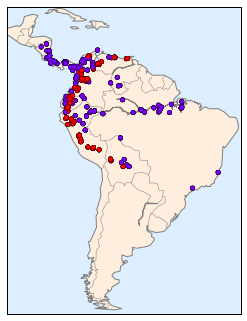

Unfortunately, this doesn't give a very good idea of the density of the species, because points in the species range may overlap one another. You may not realize it by looking at this plot, but there are over 1,600 points shown here!

Let's use kernel density estimation to show this distribution in a more interpretable way: as a smooth indication of density on the map.

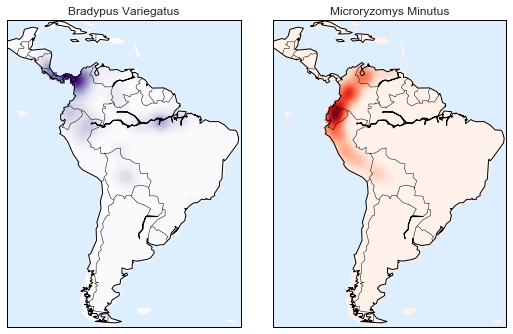